# Customer Churn Prediction using XGBoost

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis
6. Key Findings
7. Feature Engineering
8. Model Building
9. Model Evaluation
10. Save Model
11. Streamlit Application (we'll add this later)
12. Conclusion

## Project Objective

Build an XGBoost model to predict telecom customer churn using customer demographics and service information. The project includes EDA, feature engineering, model training, and deployment using Streamlit.

# EDA TO GET BUISNESS INSIGHTS

In [13]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
pd.set_option('display.max_columns', None)

In [15]:
df = pd.read_csv("../data/customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.shape

(7043, 21)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
# investigating total charges

df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [20]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [21]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [22]:
df1 = df.copy()
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df1 = df1[df1["TotalCharges"] != " "]

In [24]:
df1["TotalCharges"] = pd.to_numeric(df1["TotalCharges"])

In [25]:
df1.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [26]:
df1.duplicated().sum()

np.int64(0)

In [27]:
df1.nunique()

customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [28]:
df1["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [29]:
df1["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

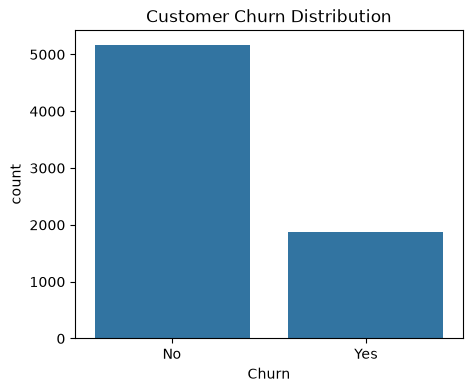

In [30]:
plt.figure(figsize=(5,4))

sns.countplot(x="Churn", data=df1)

plt.title("Customer Churn Distribution")
plt.show()

# inspecting contract feature

In [31]:
pd.crosstab(df1["Contract"], df1["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [32]:
pd.crosstab(df1["Contract"], df1["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


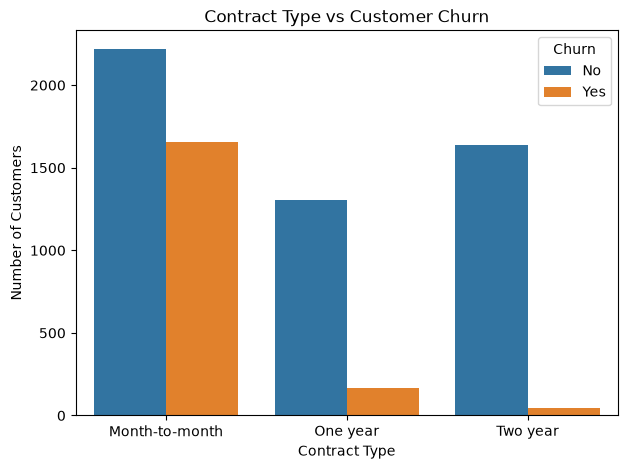

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(x="Contract", hue="Churn", data=df1)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Customers with month-to-month contracts exhibit the highest churn rate (42.7%), whereas customers with two-year contracts rarely churn (2.8%). This suggests contract duration is a strong indicator of customer retention.

# inspecting tenure feature

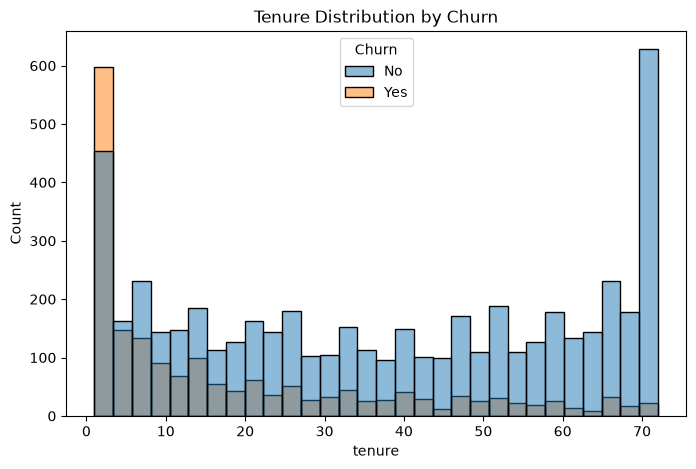

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(data=df1, x="tenure", hue="Churn", bins=30)

plt.title("Tenure Distribution by Churn")
plt.show()

In [35]:
df1.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


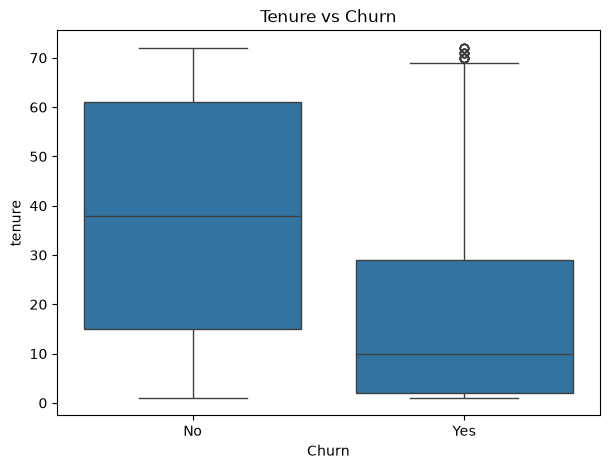

In [36]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="tenure", data=df1)

plt.title("Tenure vs Churn")
plt.show()

Customers with shorter tenure exhibit a much higher churn rate compared to long-term customers. The majority of churn occurs within the first few months of service, while customers with higher tenure are more likely to remain with the company. This indicates that tenure is a strong predictor of customer churn.

# inspecting monthly charges feature

In [37]:
df1.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


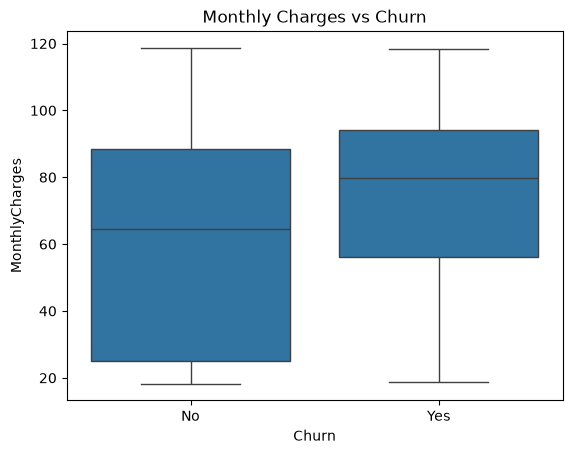

In [38]:
plt.Figure(figsize=(7,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df1)

plt.title("Monthly Charges vs Churn")
plt.show()

Customers who churn tend to have higher monthly charges than customers who stay. The median monthly charge for churned customers is ₹79.65, compared to ₹64.45 for retained customers. This indicates that higher monthly charges are associated with an increased likelihood of churn, making MonthlyCharges an important feature for churn prediction.

# inspecting Internet Service

In [39]:
pd.crosstab(
    df1["InternetService"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


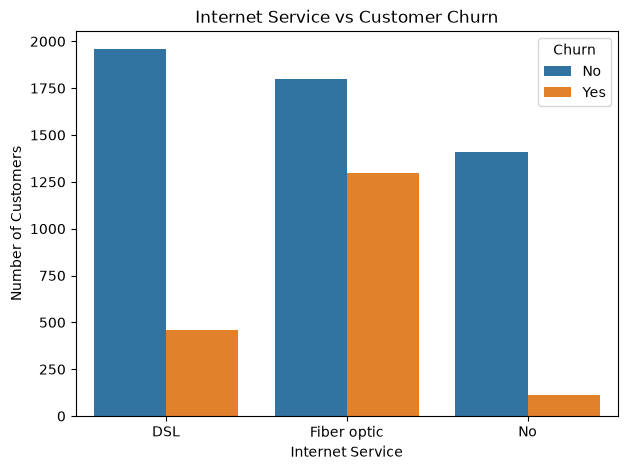

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df1
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

Internet service type has a strong relationship with customer churn. Customers using Fiber Optic internet exhibit the highest churn rate (41.9%), whereas customers without internet service have the lowest churn rate (7.4%). This suggests that InternetService is an important predictor of customer churn.

# inspecting payment method

In [41]:
pd.crosstab(
    df1["PaymentMethod"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


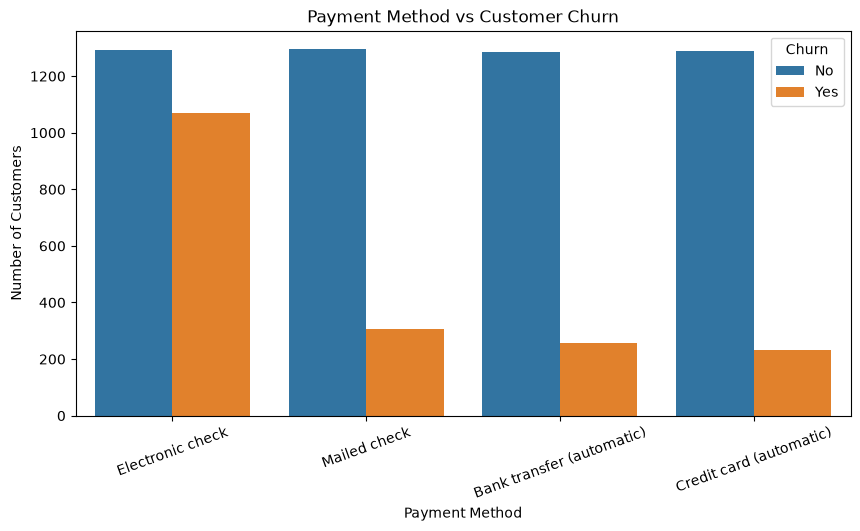

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df1
)

plt.xticks(rotation=20)
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.show()

Customers using Electronic Check exhibit the highest churn rate (45.3%), whereas customers using automatic payment methods such as Credit Card and Bank Transfer have significantly lower churn rates (around 15–17%). This suggests that payment method is an important factor associated with customer retention.

# inspecting Online Security

In [43]:
pd.crosstab(
    df1["OnlineSecurity"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


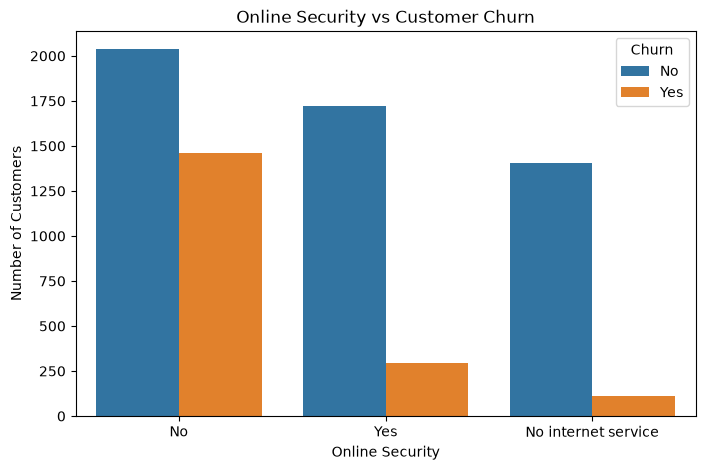

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="OnlineSecurity",
    hue="Churn",
    data=df1
)

plt.title("Online Security vs Customer Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.show()

Customers without Online Security exhibit a significantly higher churn rate (41.8%) compared to customers who subscribe to Online Security (14.6%). This suggests that customers who adopt additional value-added services are more likely to remain with the company, making OnlineSecurity an important predictor of customer churn.

# inspecting TechSupport

In [45]:
pd.crosstab(
    df1["TechSupport"],
    df1["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


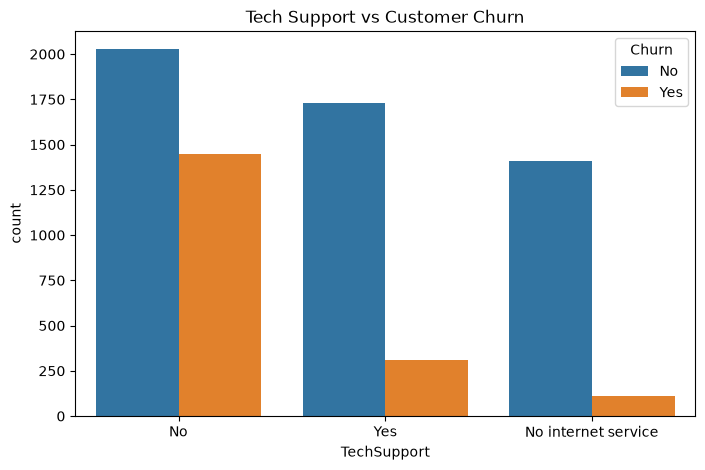

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=df1
)

plt.title("Tech Support vs Customer Churn")
plt.show()

Customers without Tech Support exhibit a significantly higher churn rate (41.6%) compared to customers who subscribe to Tech Support (15.2%). This indicates that value-added customer support services are strongly associated with improved customer retention, making TechSupport an important feature for churn prediction.

# Key Findings

### 1. Contract Type
- Customers with **month-to-month contracts** have the highest churn rate (**42.7%**).
- Customers with **two-year contracts** have the lowest churn rate (**2.8%**).
- Contract duration appears to be a strong predictor of customer churn.

### 2. Tenure
- Customers with **shorter tenure** are more likely to churn.
- Median tenure:
  - Churned customers: **10 months**
  - Retained customers: **38 months**

### 3. Monthly Charges
- Customers who churn pay **higher monthly charges**.
- Median Monthly Charges:
  - Churned customers: **₹79.65**
  - Retained customers: **₹64.45**

### 4. Internet Service
- **Fiber Optic** customers have the highest churn rate (**41.9%**).
- Customers with **no internet service** have the lowest churn rate (**7.4%**).

### 5. Payment Method
- Customers using **Electronic Check** have the highest churn rate (**45.3%**).
- Customers using **automatic payment methods** (Credit Card and Bank Transfer) have significantly lower churn rates.

### 6. Online Security
- Customers **without Online Security** have a churn rate of **41.8%**.
- Customers **with Online Security** have a churn rate of only **14.6%**.

### 7. Tech Support
- Customers **without Tech Support** have a churn rate of **41.6%**.
- Customers **with Tech Support** have a churn rate of only **15.2%**.

## MODEL BUILDING AND EVALUATION

In [47]:
# Model Building

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier

In [48]:
df2 = df1.copy()

In [49]:
df2.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5910,0856-NAOES,Male,0,No,No,6,Yes,No,DSL,No,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,60.90,414.10,No
1423,0680-DFNNY,Male,0,Yes,No,15,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.10,1504.05,Yes
1945,8229-BUJHX,Female,0,Yes,Yes,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.50,1500.95,No
6242,8265-HKSOW,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,Yes,Two year,No,Credit card (automatic),107.45,7658.30,No


In [50]:
df2.drop(columns=["customerID"], inplace=True)

In [51]:
df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df2["Churn"] = df2["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [53]:
df2["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [54]:
df2.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [55]:
df2 = pd.get_dummies(
    df2,
    drop_first=True,
    dtype=int
)

In [56]:
df2.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [57]:
df2.shape

(7032, 31)

In [58]:
df2.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes     

In [59]:
df2.isnull().sum().sum()

np.int64(0)

In [60]:
df2["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [61]:
import sys
print(sys.executable)

c:\Users\saqib\Desktop\DATA SCIENCE PROJECTS\CUSTOMER CHURN PREDICTION\venv\Scripts\python.exe


In [62]:
X = df2.drop(columns=["Churn"])
y = df2["Churn"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1


In [65]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [66]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [67]:
xgb = XGBClassifier(
    random_state=42
)

In [68]:
xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [69]:
y_pred = xgb.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7711442786069652


In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



In [72]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[888 145]
 [177 197]]


"The model has acceptable overall accuracy (77.1%), but it identifies only 53% of customers who actually churn. Since preventing customer churn is the primary objective, improving Recall should be a priority, even if it slightly reduces overall accuracy."

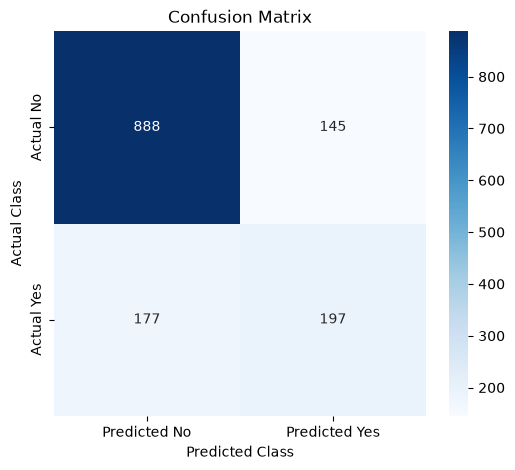

In [73]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [74]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.446928
25,Contract_Two year,0.139514
11,InternetService_No,0.092819
24,Contract_One year,0.087552
1,tenure,0.023261
23,StreamingMovies_Yes,0.020556
9,MultipleLines_Yes,0.015032
28,PaymentMethod_Electronic check,0.014753
13,OnlineSecurity_Yes,0.013672
15,OnlineBackup_Yes,0.013632


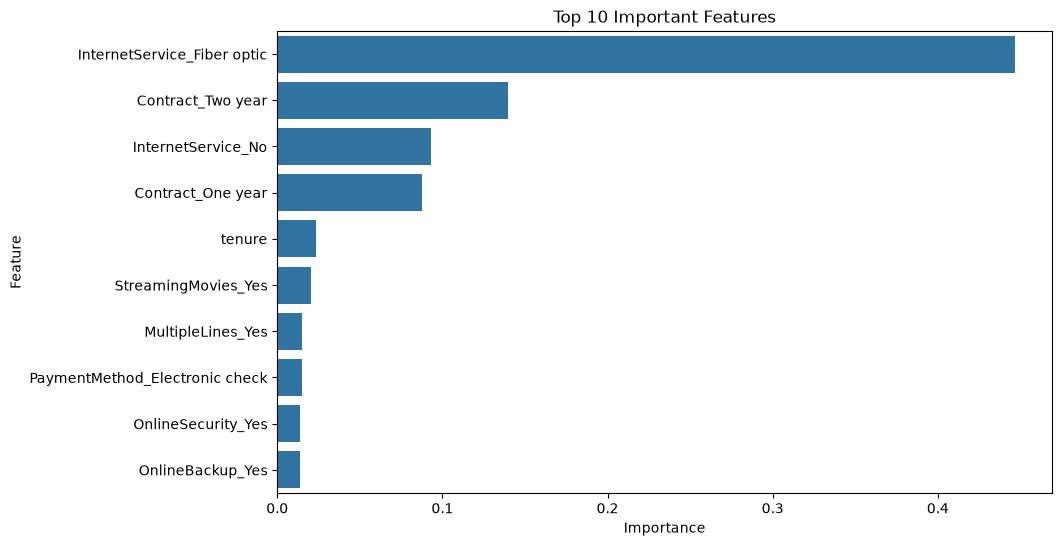

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [76]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

2.762541806020067


In [77]:
xgb_weighted = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [78]:
xgb_weighted.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [79]:
y_pred_weighted = xgb_weighted.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1033
           1       0.51      0.66      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407



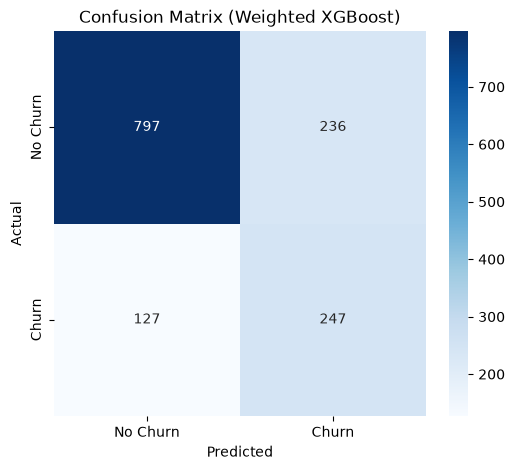

In [81]:
cm = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Weighted XGBoost)")
plt.show()

In [82]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [83]:
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="recall",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [84]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichr

In [85]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 3,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [86]:
random_search.best_score_

np.float64(0.8207357859531772)

In [87]:
best_xgb = random_search.best_estimator_

In [88]:
y_pred_final = best_xgb.predict(X_test)

In [89]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.72      0.74      1407



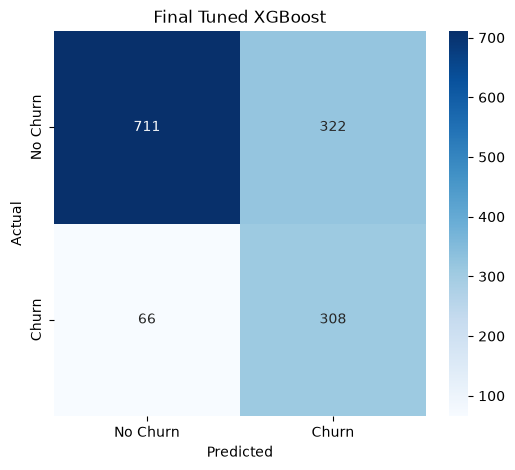

In [90]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Tuned XGBoost")
plt.show()

# Model Comparison

To improve customer churn prediction, three XGBoost models were trained and evaluated. The first model served as a baseline, the second addressed class imbalance using `scale_pos_weight`, and the third further optimized performance through hyperparameter tuning with `RandomizedSearchCV`.

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|---------:|----------:|--------:|---------:|
| Baseline XGBoost | **77.1%** | **58%** | **53%** | **55%** |
| Weighted XGBoost | **74.2%** | **51%** | **66%** | **58%** |
| Tuned XGBoost | **72.4%** | **49%** | **82%** | **61%** |

## Model Analysis

### Baseline XGBoost
- Achieved the highest overall accuracy (77.1%).
- However, it identified only **53%** of customers who actually churned.
- Suitable as a baseline but not ideal for customer retention.

### Weighted XGBoost
- Introduced `scale_pos_weight` to address class imbalance.
- Improved Recall from **53%** to **66%**.
- Accuracy decreased slightly, which is expected when prioritizing the minority class.

### Tuned XGBoost
- Optimized using `RandomizedSearchCV`.
- Achieved the highest Recall (**82%**) and best F1-score (**61%**).
- Although overall accuracy decreased to **72.4%**, the model correctly identified **308 out of 374** customers who churned, compared to only **197** using the baseline model.

## Final Model Selection

The **Tuned XGBoost** model was selected as the final model for deployment.

Although it has a lower overall accuracy, it significantly improves the model's ability to identify customers likely to churn. In a real-world telecom business, failing to identify a customer who will churn is generally more costly than incorrectly flagging a customer who would have stayed. Therefore, maximizing **Recall** aligns better with the business objective of customer retention.

**Final Selected Model:** Tuned XGBoost (RandomizedSearchCV)

In [91]:
import joblib

joblib.dump(best_xgb, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']

In [92]:
import joblib

In [93]:
joblib.dump(
    list(X_train.columns),
    "../model/model_columns.pkl"
)

['../model/model_columns.pkl']

In [96]:
X.to_csv("../data/customer_churn_processed.csv", index=False)

In [97]:
processed_data = pd.concat(
    [df1[["customerID"]].reset_index(drop=True),
     X.reset_index(drop=True)],
    axis=1
)

processed_data.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [100]:
processed_data = pd.concat(
    [df1[["customerID"]].reset_index(drop=True),
     X.reset_index(drop=True)],
    axis=1
)

processed_data.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [101]:
processed_data.shape

(7032, 31)

In [102]:
processed_data.to_csv(
    "../data/customer_churn_processed.csv",
    index=False
)

# Project Conclusion

This project developed a machine learning solution to predict customer churn for a telecommunications company using the Telco Customer Churn dataset.

The project followed a complete end-to-end machine learning workflow, including:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering using one-hot encoding
- Model training with XGBoost
- Handling class imbalance using `scale_pos_weight`
- Hyperparameter tuning using `RandomizedSearchCV`
- Model evaluation using Accuracy, Precision, Recall, F1-score, and Confusion Matrix

## Key Business Insights

- Customers with **month-to-month contracts** were significantly more likely to churn than customers with long-term contracts.
- Customers with **short tenure** showed the highest churn rates.
- **Fiber Optic** customers exhibited the highest likelihood of churning.
- Customers paying through **Electronic Check** churned more frequently than those using automatic payment methods.
- Customers without **Online Security** or **Tech Support** were considerably more likely to leave the service.

## Model Performance

Three XGBoost models were evaluated throughout the project.

| Model | Accuracy | Recall |
|-------|---------:|--------:|
| Baseline XGBoost | 77.1% | 53% |
| Weighted XGBoost | 74.2% | 66% |
| Tuned XGBoost | 72.4% | 82% |

Although the final tuned model achieved a slightly lower overall accuracy, it substantially improved Recall, successfully identifying **308 out of 374** customers who actually churned. Since the primary business objective is to identify customers at risk of leaving, Recall was prioritized over overall accuracy.

## Final Model

The final deployed model is a **Tuned XGBoost Classifier** optimized using `RandomizedSearchCV` and class weighting.

This model was selected because it best aligns with the business objective of maximizing customer retention by identifying the majority of potential churners.